## Research Summary (Week 8 Draft)

This project examines whether higher-poverty countries receive more Kiva lending per capita and whether this relationship is conditioned by institutional quality. The data consist of cross-country observations constructed from aggregated Kiva lending activity merged with World Bank governance indicators.

The main outcome variable is lending intensity measured as log loans per capita. The key explanatory variable is the national poverty rate, allowing for non-linear effects through a quadratic specification. Institutional quality—captured using a PCA-based index constructed from governance indicators (e.g., rule of law, government effectiveness, political stability)—serves as the primary conditioning mechanism.

The analysis tests whether the poverty–microfinance relationship is non-monotonic and whether stronger institutional environments enable microfinance activity to scale more effectively in poorer countries.

In [49]:
import pandas as pd
import numpy as np

# Load updated dataset (includes institutional quality variables)
df = pd.read_csv("outputs/country_master_with_finance_and_institutions.csv")
df.columns = df.columns.str.strip()

# Ensure numeric variables (coerce non-numeric to missing)
num_cols = ["population", "n_loans", "total_loan_amount", "poverty_rate", "institutional_pca1", "institutional_index"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Construct lending intensity measures
df.loc[df["population"] <= 0, "population"] = np.nan
df["loans_per_capita"] = df["n_loans"] / df["population"]
df["loan_amount_per_capita"] = df["total_loan_amount"] / df["population"]

# Main outcome used in regressions / plots
df["log_lpc"] = np.log1p(df["loans_per_capita"])

df.head()


,country_code,n_loans,total_loan_amount,population,population_below_poverty_line,poverty_rate,iso3,urban_rural_gap,atms_per_100k,bank_accounts_per_1000,...,political_stability,rule_of_law,rule_of_law_z,gov_effectiveness_z,political_stability_z,institutional_index,institutional_pca1,loans_per_capita,loan_amount_per_capita,log_lpc
0,AF,2337,1967950.0,35530081.0,35.8,0.358,AFG,0.215,1.626189,178.793210,...,-2.652540,-1.742100,-1.695679,-1.368502,-2.361683,-1.808621,-2.080862,0.000066,0.055388,0.000066
1,AL,3075,4307350.0,2930187.0,14.3,0.143,ALB,0.004,30.683033,1093.310033,...,0.110105,-0.426317,0.040005,0.540416,0.676329,0.418917,0.495336,0.001049,1.469992,0.001049
2,AM,13952,22950475.0,2930450.0,32.0,0.320,ARM,0.000,65.058099,NaN,...,-0.420025,-0.177465,0.368274,0.325854,0.093358,0.262495,0.270516,0.004761,7.831724,0.004750
3,AZ,10172,14784625.0,9827589.0,4.9,0.049,AZE,0.026,34.150007,NaN,...,-0.693411,-0.610428,-0.202860,0.454114,-0.207278,0.014659,-0.015080,0.001035,1.504400,0.001035
4,BA,608,477250.0,3507017.0,17.2,0.172,BIH,0.000,57.571467,NaN,...,-0.424812,-0.225810,0.304500,-0.303603,0.088095,0.029664,0.043444,0.000173,0.136084,0.000173


In [50]:
import pandas as pd
import numpy as np

# Ensure poverty_rate is numeric
df["poverty_rate"] = pd.to_numeric(df["poverty_rate"], errors="coerce")

# Create poverty terciles if missing
if "poverty_tercile" not in df.columns:
    df["poverty_tercile"] = pd.qcut(
        df["poverty_rate"],
        q=3,
        labels=["Low poverty", "Medium poverty", "High poverty"],
        duplicates="drop"
    )

# Ensure ordered category (for consistency in plots/tables)
df["poverty_tercile"] = pd.Categorical(
    df["poverty_tercile"],
    categories=["Low poverty", "Medium poverty", "High poverty"],
    ordered=True
)

# Quick check
df["poverty_tercile"].value_counts(dropna=False)

poverty_tercile
Low poverty       29
High poverty      29
Medium poverty    28
NaN               10
Name: count, dtype: int64

In [51]:
# Mechanism: Institutional quality conditions the poverty–microfinance relationship

# Ensure institutional quality is numeric
df["institutional_pca1"] = pd.to_numeric(df["institutional_pca1"], errors="coerce")

# Mechanism 1: Poverty × institutional quality (interaction-style mechanism variable)
df["poverty_x_institutions"] = df["poverty_rate"] * df["institutional_pca1"]

# Mechanism 2: Medium poverty + high institutions (simple subgroup indicator)
inst_med = df["institutional_pca1"].median(skipna=True)

df["medium_high_institutions"] = (
    (df["poverty_tercile"] == "Medium poverty") &
    (df["institutional_pca1"] > inst_med)
).astype(int)

df[["poverty_x_institutions", "medium_high_institutions"]].describe()

,poverty_x_institutions,medium_high_institutions
count,84.000000,96.000000
mean,-0.110570,0.093750
std,0.336237,0.293011
min,-1.352130,0.000000
25%,-0.216213,0.000000
50%,-0.016930,0.000000
75%,0.071878,0.000000
max,0.469997,1.000000


Using shapefile: data/natural_earth_countries_110m\ne_110m_admin_0_countries.shp
Match rate: 0.503


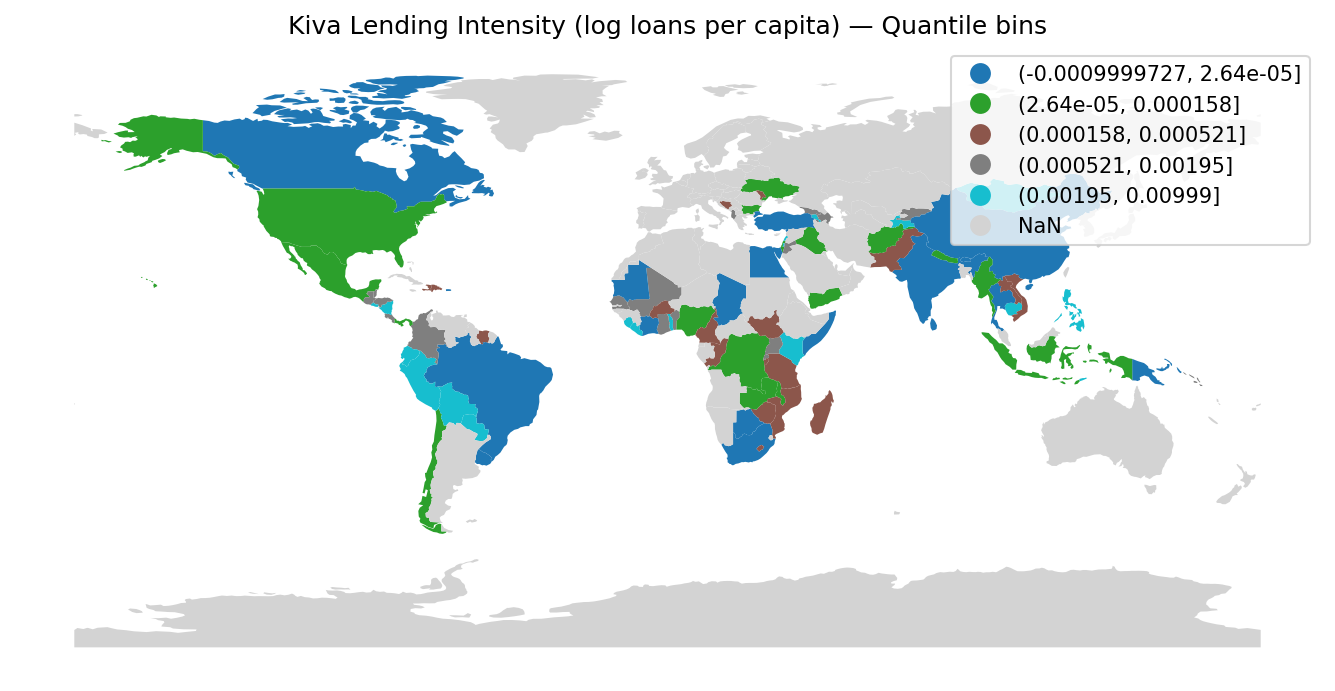

In [52]:
import os
import zipfile
import urllib.request
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ---------- settings ----------
DATA_DIR = "data/natural_earth_countries_110m"
ZIP_PATH = os.path.join(DATA_DIR, "ne_110m_admin_0_countries.zip")
URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
SHP_NAME = "ne_110m_admin_0_countries.shp"
SHP_PATH = os.path.join(DATA_DIR, SHP_NAME)

os.makedirs(DATA_DIR, exist_ok=True)

# ---------- download only if missing ----------
if not os.path.exists(ZIP_PATH) and not os.path.exists(SHP_PATH):
    print("Downloading Natural Earth countries shapefile...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("Downloaded:", ZIP_PATH)

# ---------- unzip only if shapefile missing ----------
if not os.path.exists(SHP_PATH) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

# ---------- locate .shp ----------
if not os.path.exists(SHP_PATH):
    # fallback: search for any .shp in the folder
    shp_path = None
    for f in os.listdir(DATA_DIR):
        if f.endswith(".shp") and "ne_110m_admin_0_countries" in f:
            shp_path = os.path.join(DATA_DIR, f)
            break
    if shp_path is None:
        raise FileNotFoundError(f"Could not find the shapefile in {DATA_DIR}.")
    SHP_PATH = shp_path

print("Using shapefile:", SHP_PATH)

# ---------- read world countries ----------
world = gpd.read_file(SHP_PATH)

# ---------- pick ISO3 column in shapefile ----------
iso_candidates_left = ["ISO_A3", "ADM0_A3", "SOV_A3", "WB_A3", "iso_a3"]
left_key = next((c for c in iso_candidates_left if c in world.columns), None)
if left_key is None:
    raise ValueError("No ISO3 column found in world dataset. Inspect world.columns to choose manually.")

# ---------- pick ISO3 column in df ----------
iso_candidates_right = ["iso3", "ISO3", "country_code3", "wb_iso3"]
right_key = next((c for c in iso_candidates_right if c in df.columns), None)
if right_key is None:
    raise ValueError("No ISO3 column found in df (expected one of: iso3, ISO3, country_code3, wb_iso3).")

# ---------- merge ----------
world_merged = world.merge(df, left_on=left_key, right_on=right_key, how="left")

# match rate check
match_rate = 1 - world_merged[right_key].isna().mean()
print("Match rate:", round(match_rate, 3))

# ---------- map: log loans per capita (main outcome proxy) ----------
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
world_merged["log_lpc"] = pd.to_numeric(
    world_merged.get("log_lpc"), errors="coerce"
)

# Create quantile bins manually (no mapclassify needed)
world_merged["log_lpc_bin"] = pd.qcut(
    world_merged["log_lpc"],
    q=5,
    duplicates="drop"
)

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=150)

world_merged.plot(
    column="log_lpc_bin",
    categorical=True,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Kiva Lending Intensity (log loans per capita) — Quantile bins")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [53]:
# 2) Find ISO3 key in the world file
iso_candidates_left = ["iso_a3", "ISO_A3", "ADM0_A3", "SOV_A3", "GU_A3", "WB_A3"]
left_key = next((c for c in iso_candidates_left if c in world.columns), None)

print("ISO3 key in world =", left_key)

if left_key is None:
    raise ValueError("No ISO3 column found in the world dataset. Print world.columns to inspect.")

# 3) Find ISO3 key in df
iso_candidates_right = ["iso3", "ISO3", "country_code3", "wb_iso3"]
right_key = next((c for c in iso_candidates_right if c in df.columns), None)

print("ISO3 key in df =", right_key)

if right_key is None:
    raise ValueError("No ISO3 column found in df. Check df.columns.")

# 4) Merge
world_merged = world.merge(df, left_on=left_key, right_on=right_key, how="left")

# 5) Match rate check
match_rate = 1 - world_merged[right_key].isna().mean()
print("Match rate:", round(match_rate, 3))

ISO3 key in world = ISO_A3
ISO3 key in df = iso3
Match rate: 0.503


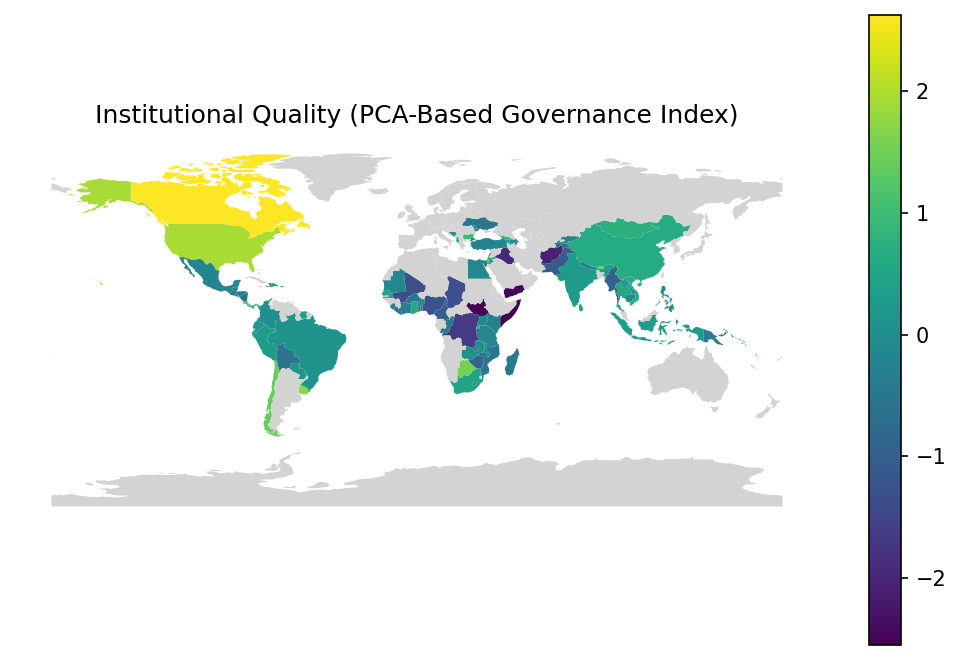

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
world_merged["institutional_pca1"] = pd.to_numeric(
    world_merged.get("institutional_pca1"),
    errors="coerce"
)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5), dpi=150)

world_merged.plot(
    column="institutional_pca1",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Institutional Quality (PCA-Based Governance Index)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

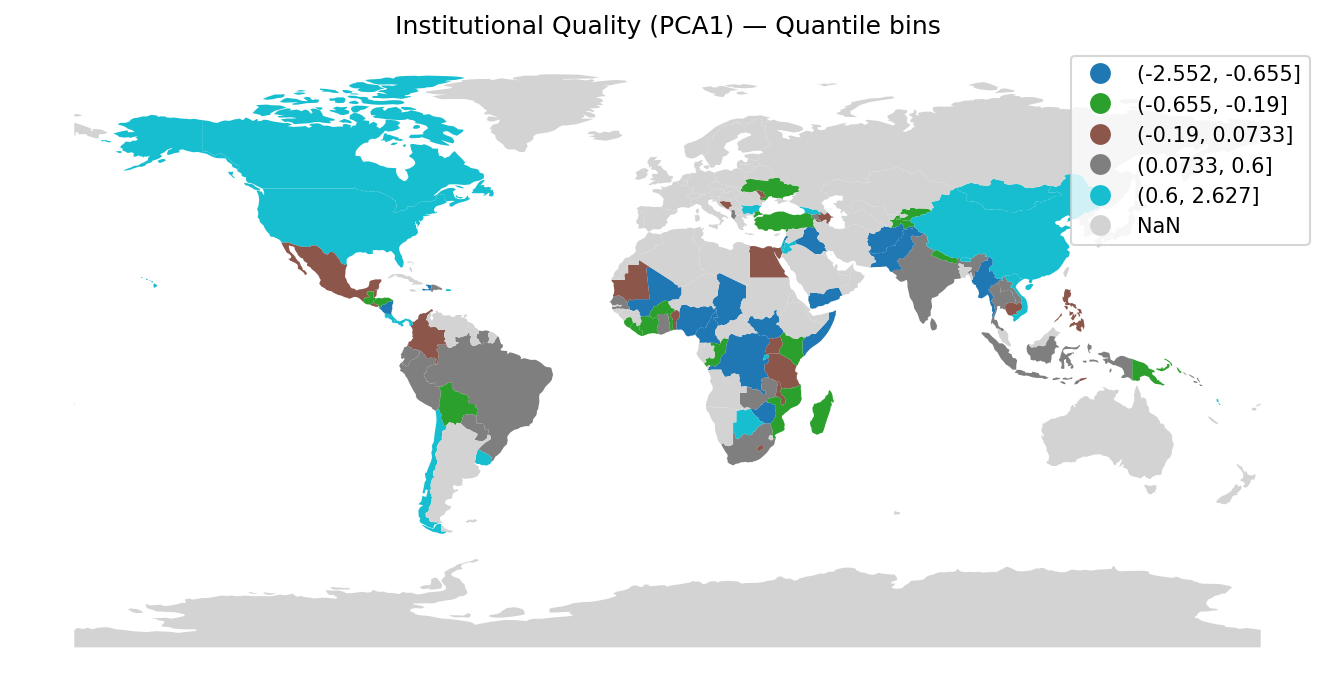

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
world_merged["institutional_pca1"] = pd.to_numeric(
    world_merged.get("institutional_pca1"), errors="coerce"
)

# Manual quantile bins (no mapclassify needed)
world_merged["inst_pca1_bin"] = pd.qcut(
    world_merged["institutional_pca1"],
    q=5,
    duplicates="drop"
)

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=150)

world_merged.plot(
    column="inst_pca1_bin",
    categorical=True,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
)

ax.set_title("Institutional Quality (PCA1) — Quantile bins")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Interpretation of the Maps

The first map displays the cross-country distribution of Kiva lending intensity, measured as log loans per capita. The spatial pattern highlights substantial heterogeneity in microfinance activity across regions, with higher lending intensity concentrated in selected countries in Latin America, parts of South Asia, and portions of Sub-Saharan Africa. Many countries exhibit very low or zero lending intensity, reflecting the uneven geographic presence of Kiva operations.

The second map presents the distribution of institutional quality, constructed using a PCA-based governance index derived from indicators such as rule of law, government effectiveness, and political stability. Institutional quality varies markedly across countries, with stronger governance environments generally observed in parts of Europe and the Americas, and weaker institutional settings in several low-income regions.

Taken together, these maps provide spatial context for the empirical analysis. While the maps do not establish causality, they illustrate cross-country variation in both lending intensity and institutional quality, motivating the regression analysis that formally tests whether institutional quality conditions the relationship between poverty and microfinance expansion. Countries shown in grey are not included in the merged analytical sample.

In [56]:
import statsmodels.api as sm

# Create non-linear term
df["poverty_rate_sq"] = df["poverty_rate"] ** 2

# Create interaction term (Project 2 mechanism)
df["poverty_x_institutions"] = (
    df["poverty_rate"] *
    df["institutional_pca1"]
)

In [57]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# -----------------------------
# Project 2 regressions (Week 8)
# Y: log loans per capita (log_lpc)
# X: poverty_rate (+ quadratic)
# Z: institutional_pca1
# -----------------------------

# Ensure numeric
for c in ["log_lpc", "poverty_rate", "institutional_pca1"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Create quadratic term
df["poverty_rate_sq"] = df["poverty_rate"] ** 2

# Create interaction term
df["poverty_x_institutions"] = df["poverty_rate"] * df["institutional_pca1"]

# Dependent variable
Y = df["log_lpc"]

# Unified regression sample (do NOT let each model pick a different sample)
base_vars = ["log_lpc", "poverty_rate", "poverty_rate_sq", "institutional_pca1", "poverty_x_institutions"]
df_reg = df.dropna(subset=["log_lpc", "poverty_rate", "institutional_pca1"]).copy()

print("Total countries:", len(df))
print("Regression sample (common):", len(df_reg))

# Model 1: linear poverty
X1 = sm.add_constant(df_reg[["poverty_rate"]])
model1 = sm.OLS(df_reg["log_lpc"], X1).fit(cov_type="HC1")

# Model 2: quadratic poverty
X2 = sm.add_constant(df_reg[["poverty_rate", "poverty_rate_sq"]])
model2 = sm.OLS(df_reg["log_lpc"], X2).fit(cov_type="HC1")

# Model 3: add institutions (Z)
X3 = sm.add_constant(df_reg[["poverty_rate", "poverty_rate_sq", "institutional_pca1"]])
model3 = sm.OLS(df_reg["log_lpc"], X3).fit(cov_type="HC1")

# Model 4: interaction poverty × institutions
X4 = sm.add_constant(df_reg[["poverty_rate", "poverty_rate_sq", "institutional_pca1", "poverty_x_institutions"]])
model4 = sm.OLS(df_reg["log_lpc"], X4).fit(cov_type="HC1")

Total countries: 96
Regression sample (common): 84


In [58]:
from stargazer.stargazer import Stargazer
from IPython.display import HTML

stargazer = Stargazer([model1, model2, model3, model4])

stargazer.title("Institutional Quality and the Poverty–Microfinance Relationship")
stargazer.custom_columns(["(1)", "(2)", "(3)", "(4)"], [1, 1, 1, 1])
stargazer.significant_digits(3)

stargazer.rename_covariates({
    "poverty_rate": "Poverty rate",
    "poverty_rate_sq": "Poverty rate (squared)",
    "institutional_pca1": "Institutional quality (PCA1)",
    "poverty_x_institutions": "Poverty × Institutional quality",
    "const": "Constant"
})

stargazer.add_line("Robust SE (HC1)", ["Yes", "Yes", "Yes", "Yes"])

display(HTML(stargazer.render_html()))

## Interpretation of Regression Results

Across specifications, the linear association between poverty and lending intensity (measured as log loans per capita) is weak. However, once a quadratic term is introduced, the relationship becomes concave (inverted-U shaped): predicted lending intensity increases with poverty at lower levels but declines at very high poverty levels. The estimated turning point lies within the observed range of poverty rates, consistent with the descriptive finding that lending intensity peaks in medium-poverty countries.

When institutional quality is introduced, the main effect of institutional quality alone is small, but the interaction term between poverty and institutional quality is positive and statistically significant. This indicates that the association between poverty and lending intensity is conditional on institutional environment. In countries with stronger governance structures, the positive effect of poverty on microfinance expansion is amplified, whereas in weaker institutional environments, this relationship is attenuated.

These findings are consistent with the hypothesis that institutional quality shapes the scalability of microfinance activity. While the analysis is cross-sectional and does not establish causality, the results provide preliminary evidence that governance conditions play an important role in mediating the poverty–microfinance relationship. Additional robustness checks and alternative specifications will be explored in the final project.